# Imports

In [ ]:
# Plotting
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Math + stats
import numpy as np
import pandas as pd
from scipy.stats import binom

# Logistics
from os.path import sep
from tqdm import tqdm
import time

# Local modules
import edu_nested_simulation_functions
import disc_score
import AS_extract_data_from_dta_file

# Enable re-load of local modules every time they are called
%load_ext autoreload
%autoreload 2
%aimport numpy 
%aimport pandas

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data

Taken from [this dataset](https://zenodo.org/records/10727363), which accompanies [this paper](https://academic.oup.com/ej/article/134/661/2207/7625080#467883597). 

## Data path

In [223]:
data_folder = 'Documents{0}Github{0}CEGIS{0}DiscSim_figures_and_data{0}Abhijit Singh 2024 AP audit data{0}Data{0}Raw_data'.format(sep)

## Paper test (L0 data)

In [224]:
filepath = '{0}{1}ap_paper_pooled.csv'.format(data_folder, sep)
L0_data = pd.read_csv(filepath)

In [225]:
L0_data

,StudentID,an_schcd,Schoolmanagement,Tablet,Tablet_a,Class,Gender,setType,eq1,eq2,...,math_per,english_per,telugu_per,math_total_common,english_total_common,telugu_total_common,math_per_common,english_per_common,telugu_per_common,p_tab
0,12721,63638,NaN,NaN,NaN,4,F,3.0,NaN,1.0,...,43.333332,33.333332,76.666664,12,6,18,50.000000,25.000000,75.000000,NaN
1,12718,63638,NaN,NaN,NaN,4,F,3.0,NaN,1.0,...,63.333332,70.000000,76.666664,15,21,20,62.500000,87.500000,83.333336,NaN
2,12723,63638,NaN,NaN,NaN,4,F,1.0,1.0,1.0,...,50.000000,56.666668,83.333336,14,14,21,58.333332,58.333332,87.500000,NaN
3,12719,63638,NaN,NaN,NaN,4,F,1.0,1.0,1.0,...,93.333336,93.333336,93.333336,22,22,23,91.666664,91.666664,95.833336,NaN
4,12722,63638,NaN,NaN,NaN,4,F,2.0,NaN,1.0,...,60.000000,63.333332,80.000000,16,14,19,66.666664,58.333332,79.166664,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12748,12713,12933,33-MPP_ZPP SCHOOLS,0.0,0.0,4,M,1.0,0.0,0.0,...,23.333334,23.333334,13.333333,6,6,3,25.000000,25.000000,12.500000,0.0
12749,12714,12933,33-MPP_ZPP SCHOOLS,0.0,0.0,4,M,1.0,1.0,1.0,...,23.333334,43.333332,46.666668,6,10,10,25.000000,41.666668,41.666668,0.0
12750,12711,12933,33-MPP_ZPP SCHOOLS,0.0,0.0,4,M,2.0,NaN,1.0,...,36.666668,30.000000,30.000000,10,7,8,41.666668,29.166666,33.333332,0.0
12751,12716,12933,33-MPP_ZPP SCHOOLS,0.0,0.0,4,F,1.0,1.0,1.0,...,30.000000,43.333332,70.000000,7,10,16,29.166666,41.666668,66.666664,0.0


## L2 data - external audit

In [226]:
filepath = '{0}{1}ap_retest_pooled.csv'.format(data_folder, sep)
L2_data = pd.read_csv(filepath)

In [227]:
L2_data

,ID,StudentID,an_schcd,Tablet,Tablet_a,Sample,Class,gender,eq1,eq2,...,english_per,telugu_per,math_total_common,english_total_common,telugu_total_common,math_per_common,english_per_common,telugu_per_common,Schoolmanagement,p_tab
0,1863,4.859257e+06,37494,1,1,1,4,F,0,1,...,20.000000,46.666668,7,6,11,29.166666,25.000000,45.833332,33-MPP_ZPP SCHOOLS,1.0
1,1860,4.840747e+06,37494,1,1,1,4,F,0,0,...,3.333333,23.333334,1,1,6,4.166666,4.166666,25.000000,33-MPP_ZPP SCHOOLS,1.0
2,1862,4.859240e+06,37494,1,1,1,4,F,0,0,...,26.666666,46.666668,7,7,11,29.166666,29.166666,45.833332,33-MPP_ZPP SCHOOLS,1.0
3,1857,4.840739e+06,37494,1,1,1,4,F,0,1,...,30.000000,50.000000,11,7,12,45.833332,29.166666,50.000000,33-MPP_ZPP SCHOOLS,1.0
4,1861,4.840710e+06,37494,1,1,1,4,F,0,0,...,6.666666,13.333333,2,2,3,8.333333,8.333333,12.500000,33-MPP_ZPP SCHOOLS,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4075,2691,1.550554e+12,50781,1,1,1,4,F,1,1,...,26.666666,66.666664,10,6,15,41.666668,25.000000,62.500000,38-Pvt.Unaided,1.0
4076,2696,NaN,50781,1,1,1,5,F,1,1,...,33.333332,46.666668,7,6,11,29.166666,25.000000,45.833332,38-Pvt.Unaided,1.0
4077,2693,NaN,50781,1,1,1,5,F,1,1,...,46.666668,86.666664,15,11,20,62.500000,45.833332,83.333336,38-Pvt.Unaided,1.0
4078,2694,NaN,50781,1,1,1,5,M,1,1,...,33.333332,43.333332,7,7,11,29.166666,29.166666,45.833332,38-Pvt.Unaided,1.0


## Cleaned data from dataset accompanying paper

In [6]:
cd

/Users/amrita


In [228]:
cleaned_data_folder = data_folder = 'Documents{0}Github{0}CEGIS{0}DiscSim_figures_and_data{0}Abhijit Singh 2024 AP audit data{0}Data{0}Constructed_data'.format(sep)
filepath = '{0}{1}ap_pooled_tablet_paper_retest.dta'.format(cleaned_data_folder, sep)

cleaned_data = AS_extract_data_from_dta_file.extract_data_from_dta(filepath)

In [229]:
cleaned_data

,studentid,an_schcd,MandalName,tablet,tablet_a,tabletdata,schoolmanagement,management,private,female,...,retest_eq42,retest_eq43,retest_eq44,retest_eq45,retest_eq46,retest_eq47,retest_eq48,p_tab,ID,merge_retest
0,4.807500e+06,4.0,TALLURU,1.0,1.0,1.0,33-MPP_ZPP SCHOOLS,6.0,Government,Female,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,master only (1)
1,4.887478e+06,4.0,TALLURU,1.0,1.0,1.0,33-MPP_ZPP SCHOOLS,6.0,Government,Female,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,master only (1)
2,1.550653e+12,4.0,TALLURU,1.0,1.0,1.0,33-MPP_ZPP SCHOOLS,6.0,Government,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,master only (1)
3,1.550653e+12,4.0,TALLURU,1.0,1.0,1.0,33-MPP_ZPP SCHOOLS,6.0,Government,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,master only (1)
4,4.807503e+06,4.0,TALLURU,1.0,1.0,1.0,33-MPP_ZPP SCHOOLS,6.0,Government,Male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,master only (1)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39259,1.390000e+02,63642.0,,NaN,NaN,0.0,,NaN,NaN,Male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,master only (1)
39260,1.350000e+02,63642.0,,NaN,NaN,0.0,,NaN,NaN,Male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,master only (1)
39261,1.380000e+02,63642.0,,NaN,NaN,0.0,,NaN,NaN,Female,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,master only (1)
39262,1.370000e+02,63642.0,,NaN,NaN,0.0,,NaN,NaN,Female,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,master only (1)


# Calculate discrepancy

## Merge datasets on student ID

### Using raw data

In [230]:
L0_student_id = L0_data.StudentID
L2_student_id = [int(i) for i in L2_data.StudentID if not np.isnan(i) and not np.isinf(i)]

L0_match_indices = [i for i in range(len(L0_student_id)) if L0_student_id[i] in L2_student_id]
L2_match_indices = [np.where(L2_student_id == L0_student_id[i])[0][0] for i in L0_match_indices]

n_students = len(L0_match_indices)
print('{0} matching student IDs'.format(n_students))

# Make sure L0 and L2 student IDs match
assert(np.sum(np.abs([L0_student_id[L0_match_indices[i]] - L2_student_id[L2_match_indices[i]] 
                      for i in range(n_students)])) == 0)

776 matching student IDs


#### Check for duplicate IDs

In [15]:
len(np.unique([L0_student_id[L0_match_indices[i]] 
                      for i in range(n_students)]))

776

In [30]:
num_L2_student_IDs_repeated = 0
L0_match_indices_repeated = []
for i in L0_match_indices:
    n = len(np.where(L2_student_id == L0_student_id[i])[0])
    if n > 1:
        num_L2_student_IDs_repeated += 1
        L0_match_indices_repeated.append(i)
    elif n < 1:
        print(i)
        break

In [29]:
num_L2_student_IDs_repeated

25

In [31]:
L0_match_indices_repeated

[1744,
 1765,
 3272,
 3643,
 3650,
 4372,
 4373,
 4528,
 4531,
 4532,
 4533,
 4536,
 4538,
 4579,
 4590,
 4720,
 4738,
 4774,
 5018,
 5049,
 5075,
 5125,
 5570,
 5928,
 8431]

In [39]:
np.where(L2_student_id == L0_student_id[5125])

(array([819, 821]),)

In [40]:
L0_student_id[5125]

5128

In [41]:
np.where(L2_student_id == 5128)

(array([], dtype=int64),)

In [43]:
np.where(L2_data.StudentID == L0_student_id[5125])

(array([1828, 1831]),)

In [44]:
L2_data.iloc[1828]

ID                                          3937
StudentID                                 5128.0
an_schcd                                   37968
Tablet                                         0
Tablet_a                                       0
                                 ...            
math_per_common                        83.333336
english_per_common                     54.166668
telugu_per_common                      41.666668
Schoolmanagement      27-APTWREI Society Schools
p_tab                                   0.388889
Name: 1828, Length: 166, dtype: object

In [45]:
L2_data.iloc[1831]

ID                                          3942
StudentID                                 5128.0
an_schcd                                   37968
Tablet                                         0
Tablet_a                                       0
                                 ...            
math_per_common                             62.5
english_per_common                     41.666668
telugu_per_common                      33.333332
Schoolmanagement      27-APTWREI Society Schools
p_tab                                   0.388889
Name: 1831, Length: 166, dtype: object

In [27]:
np.where(L2_student_id == L0_student_id[i])[0]

array([1735])

In [22]:
np.where(L2_student_id == L2_student_id[i])

(array([], dtype=int64),)

In [24]:
L2_student_id.index(L2_student_id[i])

1735

### Using cleaned data

In [231]:
# Select rows in cleaned dataset which are paper tests (tablet = 0) and valid merges
cleaned_data_merge_rows = np.where(np.logical_and(cleaned_data.merge_retest == 'matched (3)', 
                                                  cleaned_data.tablet == 0))[0]
print('{0} students merged'.format(len(cleaned_data_merge_rows)))
n_students_clean = len(cleaned_data_merge_rows)

cleaned_data_merge_student_ids = [cleaned_data.studentid[i] for i in cleaned_data_merge_rows]

770 students merged


### Compare merged student IDs from raw and cleaned data

In [67]:
raw_data_merge_student_ids = [L0_student_id[L0_match_indices[i]] for i in range(n_students)]

raw_clean_student_ids = [i for i in cleaned_data_merge_student_ids if i in raw_data_merge_student_ids]
print('{0} student IDs are present in both raw and cleaned merged datasets'.format(len(raw_clean_student_ids)))

770 student IDs are present in both raw and cleaned merged datasets


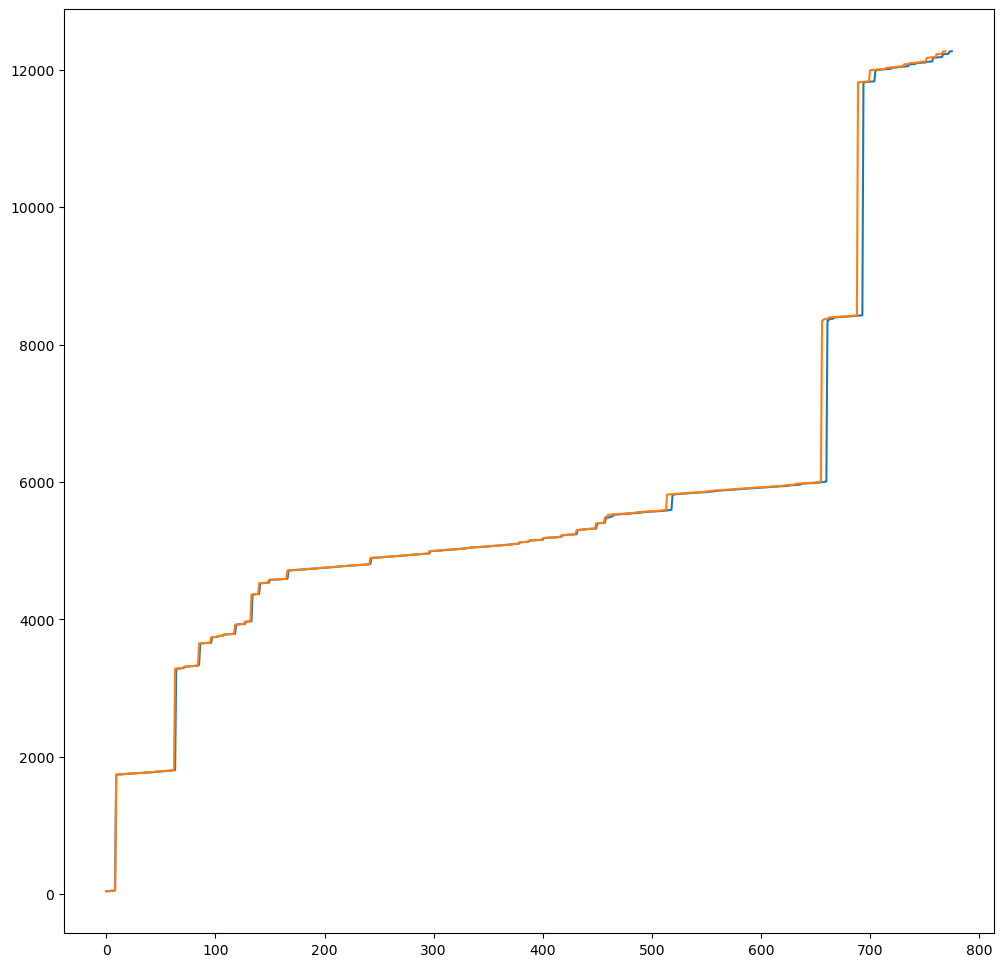

In [71]:
plt.figure(figsize = [12, 12])
plt.plot(np.sort(raw_data_merge_student_ids))
plt.plot(np.sort(cleaned_data_merge_student_ids))

## Get score for each subject

### From raw data

In [232]:
L0_scores = {
    'Maths': [L0_data.math_per_common[i] for i in L0_match_indices],
    'English': [L0_data.english_per_common[i] for i in L0_match_indices],
    'Telugu': [L0_data.telugu_per_common[i] for i in L0_match_indices],
            }

L2_scores = {
    'Maths': [L2_data.math_per_common[i] for i in L2_match_indices],
    'English': [L2_data.english_per_common[i] for i in L2_match_indices],
    'Telugu': [L2_data.telugu_per_common[i] for i in L2_match_indices],
            }

### From cleaned data

In [233]:
L0_scores_clean = {
    'Maths': [cleaned_data.csf_math_per_common[i] for i in cleaned_data_merge_rows],
    'English': [cleaned_data.csf_english_per_common[i] for i in cleaned_data_merge_rows],
    'Telugu': [cleaned_data.csf_telugu_per_common[i] for i in cleaned_data_merge_rows],
            }

L2_scores_clean = {
    'Maths': [cleaned_data.retest_math_per_common[i] for i in cleaned_data_merge_rows],
    'English': [cleaned_data.retest_english_per_common[i] for i in cleaned_data_merge_rows],
    'Telugu': [cleaned_data.retest_telugu_per_common[i] for i in cleaned_data_merge_rows],
            }

## Plot scores for each subject

### Scatter plots

#### Raw data

Text(0, 0.5, 'Teacher score')

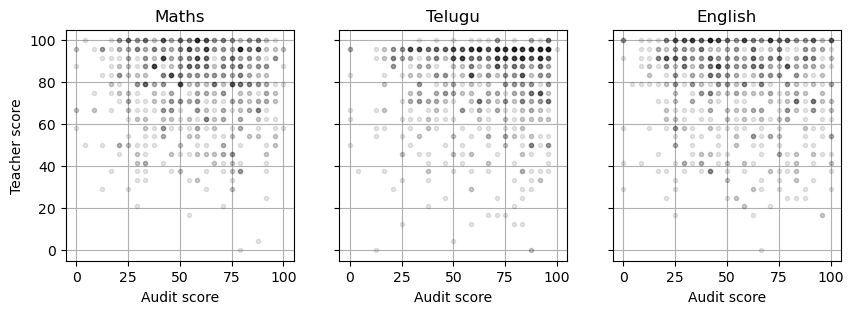

In [91]:
fig, ax = plt.subplots(nrows = 1, ncols = 3, sharex = True, sharey = True, figsize = [10, 3])
ax[0].set_xlim([-5, 105])
ax[0].set_ylim([-5, 105])

i = 0
for subject in ['Maths', 'Telugu', 'English']:
    ax[i].scatter(L2_scores[subject], L0_scores[subject], color = 'k', marker = '.', zorder = 10,
                 alpha = 0.1)
    ax[i].set_xlabel('Audit score')
    ax[i].grid(zorder = 2)
    ax[i].set_title(subject)
    i += 1

ax[0].set_ylabel('Teacher score')

#### Cleaned data

Maths
  Mean: 61.77000045776367
  Std. dev.: 20.65999984741211
Telugu
  Mean: 68.05000305175781
  Std. dev.: 21.43000030517578
English
  Mean: 63.65999984741211
  Std. dev.: 23.549999237060547


Text(0, 0.5, 'Teacher score (cleaned)')

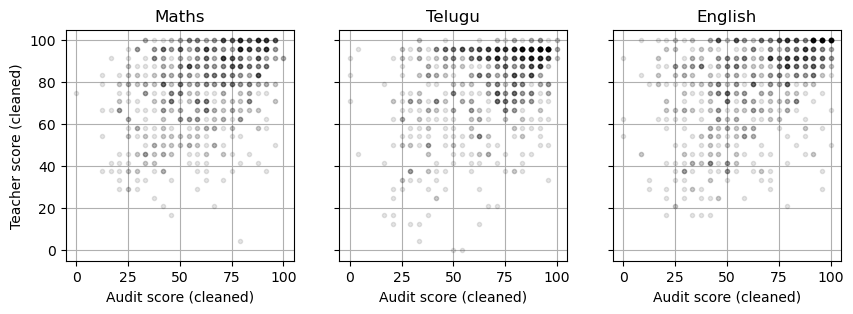

In [107]:
fig, ax = plt.subplots(nrows = 1, ncols = 3, sharex = True, sharey = True, figsize = [10, 3])
ax[0].set_xlim([-5, 105])
ax[0].set_ylim([-5, 105])

i = 0
for subject in ['Maths', 'Telugu', 'English']:
    ax[i].scatter(L2_scores_clean[subject], L0_scores_clean[subject], color = 'k', marker = '.', zorder = 10,
                 alpha = 0.1)
    ax[i].set_xlabel('Audit score (cleaned)')
    ax[i].grid(zorder = 2)
    ax[i].set_title(subject)
    
    print(subject)
    print('  Mean: {0}'.format(np.round(np.mean(L2_scores_clean[subject]), 2)))
    print('  Std. dev.: {0}'.format(np.round(np.std(L2_scores_clean[subject], ddof = 1), 2)))
    
    i += 1

ax[0].set_ylabel('Teacher score (cleaned)')



### 2D histogram

#### Raw data

Text(0, 0.5, 'Teacher score')

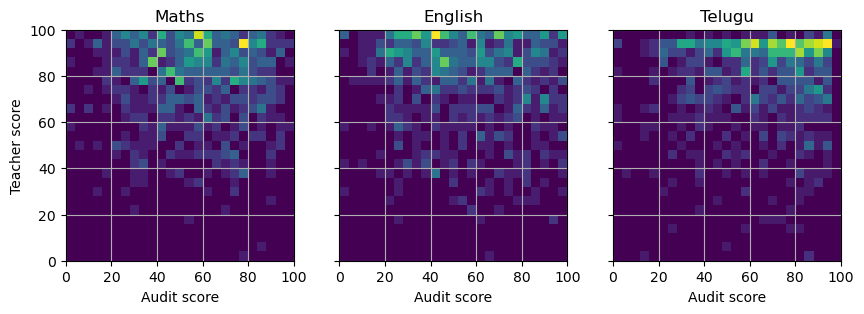

In [77]:
fig, ax = plt.subplots(nrows = 1, ncols = 3, sharex = True, sharey = True, figsize = [10, 3])
ax[0].set_xlim([-5, 105])
ax[0].set_ylim([-5, 105])

i = 0
for subject in ['Maths', 'English', 'Telugu']:
    ax[i].hist2d(L2_scores[subject], L0_scores[subject], bins = 25)
    ax[i].set_xlabel('Audit score')
    ax[i].grid(zorder = 2)
    ax[i].set_title(subject)
    i += 1

ax[0].set_ylabel('Teacher score')

#### Cleaned data

Text(0, 0.5, 'Teacher score')

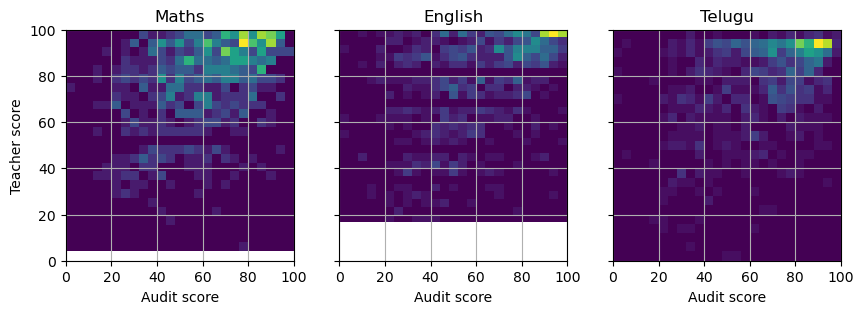

In [75]:
fig, ax = plt.subplots(nrows = 1, ncols = 3, sharex = True, sharey = True, figsize = [10, 3])
ax[0].set_xlim([-5, 105])
ax[0].set_ylim([-5, 105])

i = 0
for subject in ['Maths', 'English', 'Telugu']:
    ax[i].hist2d(L2_scores_clean[subject], L0_scores_clean[subject], bins = 25)
    ax[i].set_xlabel('Audit score')
    ax[i].grid(zorder = 2)
    ax[i].set_title(subject)
    i += 1

ax[0].set_ylabel('Teacher score')

### Audit score distribution

#### Cleaned data

Text(0, 0.5, 'Frequency')

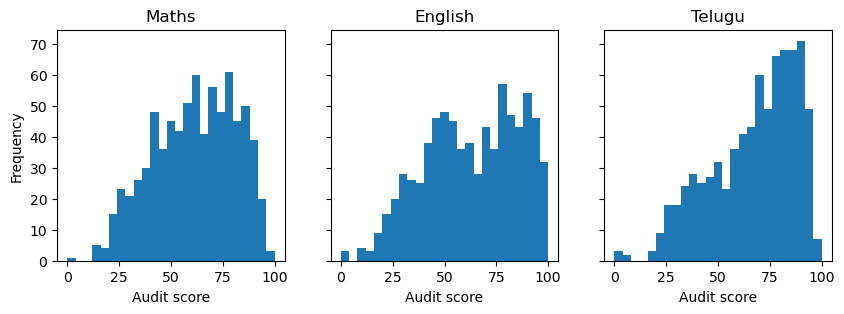

In [11]:
fig, ax = plt.subplots(nrows = 1, ncols = 3, sharex = True, sharey = True, figsize = [10, 3])
ax[0].set_xlim([-5, 105])
#ax[0].set_ylim([-5, 105])

i = 0
for subject in ['Maths', 'English', 'Telugu']:
    ax[i].hist(L2_scores_clean[subject], bins = 25)
    ax[i].set_xlabel('Audit score')
    ax[i].set_title(subject)
    i += 1

ax[0].set_ylabel('Frequency')

## Discrepancy

### Raw data

Text(0, 0.5, 'Discrepancy (teacher - audit)')

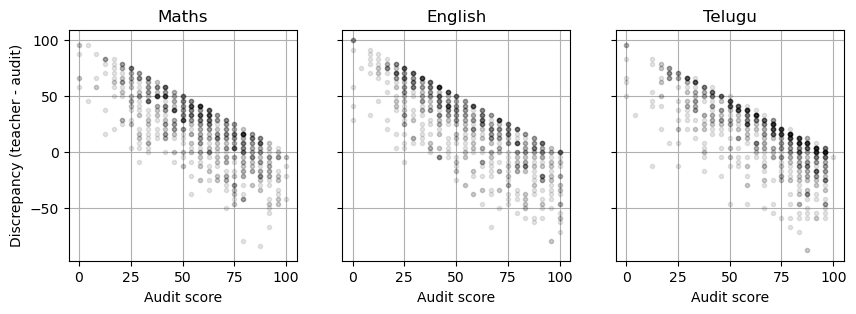

In [234]:
discrepancy_method = 'simple_difference' # L0 minus L2
disc = {subject: [disc_score.discrepancy_score(L0_scores[subject][i], L2_scores[subject][i],
                                              discrepancy_method) for i in range(n_students)] 
       for subject in ['Maths', 'English', 'Telugu']}

fig, ax = plt.subplots(nrows = 1, ncols = 3, sharex = True, sharey = True, figsize = [10, 3])
ax[0].set_xlim([-5, 105])
#ax[0].set_ylim([-5, 105])

i = 0
for subject in ['Maths', 'English', 'Telugu']:
    ax[i].scatter(L2_scores[subject], disc[subject], color = 'k', marker = '.', zorder = 10,
                 alpha = 0.1)
    ax[i].set_xlabel('Audit score')
    ax[i].grid(zorder = 2)
    ax[i].set_title(subject)
    i += 1

ax[0].set_ylabel('Discrepancy (teacher - audit)')

### Cleaned data

Text(0, 0.5, 'Discrepancy (clean)\n(teacher - audit)')

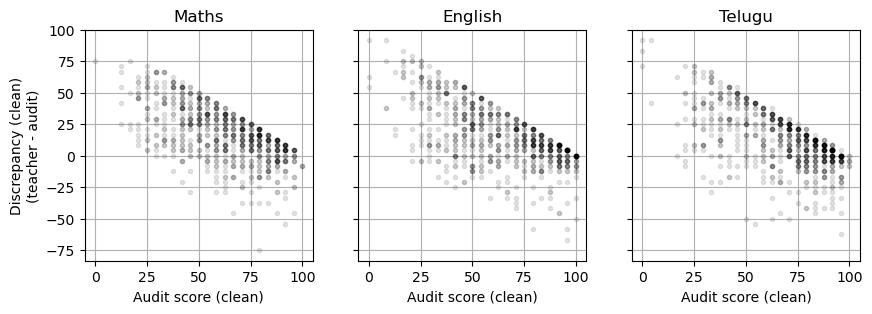

In [13]:
discrepancy_method = 'simple_difference' # L0 minus L2
disc_clean = {subject: [disc_score.discrepancy_score(L0_scores_clean[subject][i], L2_scores_clean[subject][i],
                                              discrepancy_method) for i in range(n_students_clean)] 
       for subject in ['Maths', 'English', 'Telugu']}

fig, ax = plt.subplots(nrows = 1, ncols = 3, sharex = True, sharey = True, figsize = [10, 3])
ax[0].set_xlim([-5, 105])

i = 0
for subject in ['Maths', 'English', 'Telugu']:
    ax[i].scatter(L2_scores_clean[subject], disc_clean[subject], color = 'k', marker = '.', zorder = 10,
                 alpha = 0.1)
    ax[i].set_xlabel('Audit score (clean)')
    ax[i].grid(zorder = 2)
    ax[i].set_title(subject)
    i += 1

ax[0].set_ylabel('Discrepancy (clean)\n(teacher - audit)')

## Average discrepancy for a particular audit score

### Raw data

/Users/amrita/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/amrita/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Text(0, 0.5, 'Discrepancy (teacher - audit)')

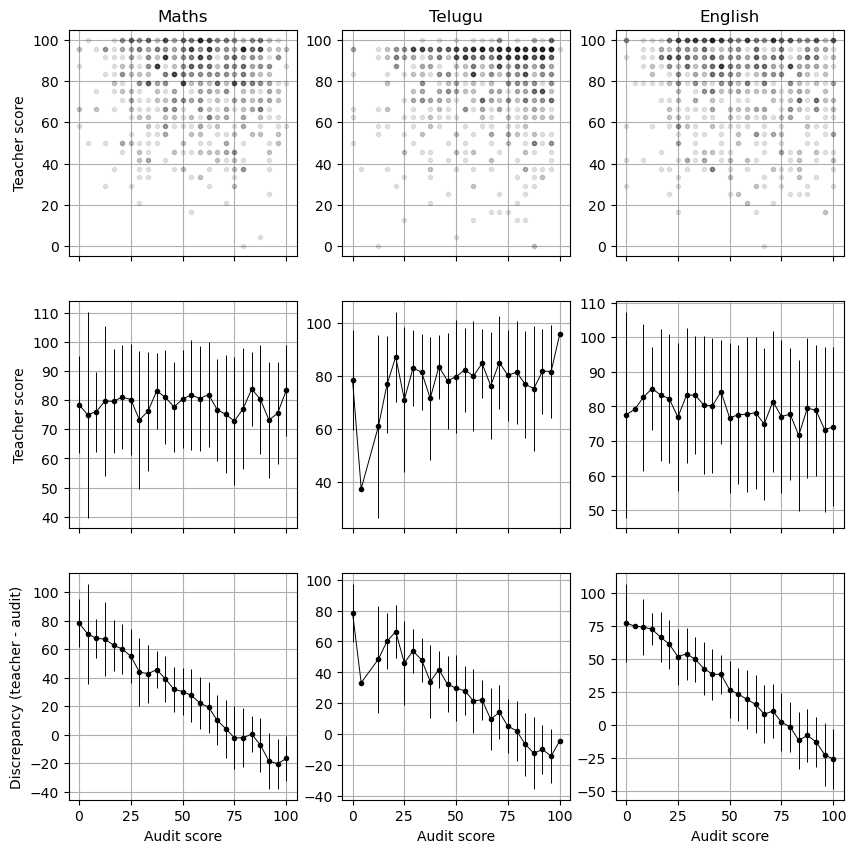

In [14]:
L0_scores_by_L2_score = {}

fig, ax = plt.subplots(nrows = 3, ncols = 3, sharex = True, sharey = False, figsize = [10, 10])
ax[0, 0].set_xlim([-5, 105])
#ax[0].set_ylim([-5, 105])

col = 0
for subject in ['Maths', 'Telugu', 'English']:
    
    L2_unique = np.unique(L2_scores[subject])
    n_L2_unique = len(L2_unique)
    L0_scores_by_L2_score[subject] = {i: [L0_scores[subject][j] 
                                     for j in np.where(L2_scores[subject] == L2_unique[i])[0].astype(int)] 
                                 for i in range(n_L2_unique)}
    for j in range(n_L2_unique):
        
        n_L0_scores = len(L0_scores_by_L2_score[subject][j])
        
        # Scatter plot - all L0 scores for a particular L2 score
        ax[0, col].scatter(np.ones(n_L0_scores)*L2_unique[j], L0_scores_by_L2_score[subject][j], 
                        color = 'k', marker = '.', zorder = 10,
                     alpha = 0.1)
        
    # Line plot - mean and variance of L0 scores for a particular L2 score
    ax[1, col].errorbar(L2_unique, [np.mean(L0_scores_by_L2_score[subject][j]) for j in range(n_L2_unique)],
                        [np.std(L0_scores_by_L2_score[subject][j], ddof = 1) for j in range(n_L2_unique)],
                    color = 'k', marker = '.', zorder = 10, linewidth = 0.7,
                 alpha = 1)
    
    # Mean and variance of discrepancy for a particular L2 score
    ax[2, col].errorbar(L2_unique, [np.mean(L0_scores_by_L2_score[subject][j] - L2_unique[j]) for j in range(n_L2_unique)],
                        [np.std(L0_scores_by_L2_score[subject][j] - L2_unique[j], ddof = 1) for j in range(n_L2_unique)],
                    color = 'k', marker = '.', zorder = 10, linewidth = 0.7,
                 alpha = 1)
        
    ax[2, col].set_xlabel('Audit score')
    ax[0, col].grid(zorder = 2)
    ax[1, col].grid()
    ax[2, col].grid()
    ax[0, col].set_title(subject)
    col += 1

for row in range(2):
    ax[row, 0].set_ylabel('Teacher score')
ax[2, 0].set_ylabel('Discrepancy (teacher - audit)')

Note negative discrepancies when audit scores are high (i.e. teachers appear to be incorrectly reducing marks for students who score very high on the external test).

### Cleaned data

/Users/amrita/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/amrita/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


Text(0, 0.5, 'Discrepancy (clean)\n(teacher - audit)')

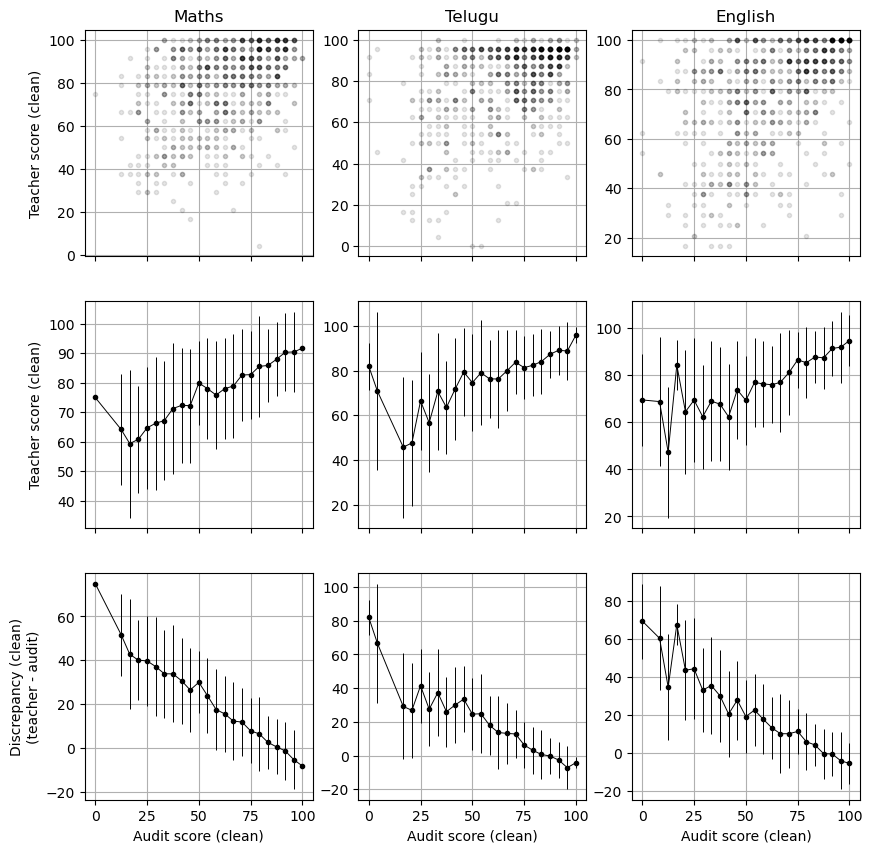

In [14]:
L0_scores_by_L2_score_clean = {}

fig, ax = plt.subplots(nrows = 3, ncols = 3, sharex = True, sharey = False, figsize = [10, 10])
ax[0, 0].set_xlim([-5, 105])

col = 0
for subject in ['Maths', 'Telugu', 'English']:
    
    L2_unique = np.unique(L2_scores_clean[subject])
    n_L2_unique = len(L2_unique)
    L0_scores_by_L2_score_clean[subject] = {i: [L0_scores_clean[subject][j] 
                                     for j in np.where(L2_scores_clean[subject] == L2_unique[i])[0].astype(int)] 
                                 for i in range(n_L2_unique)}
    for j in range(n_L2_unique):
        
        n_L0_scores = len(L0_scores_by_L2_score_clean[subject][j])
        
        # Scatter plot - all L0 scores for a particular L2 score
        ax[0, col].scatter(np.ones(n_L0_scores)*L2_unique[j], L0_scores_by_L2_score_clean[subject][j], 
                        color = 'k', marker = '.', zorder = 10,
                     alpha = 0.1)
        
    # Line plot - mean and variance of L0 scores for a particular L2 score
    ax[1, col].errorbar(L2_unique, [np.mean(L0_scores_by_L2_score_clean[subject][j]) for j in range(n_L2_unique)],
                        [np.std(L0_scores_by_L2_score_clean[subject][j], ddof = 1) for j in range(n_L2_unique)],
                    color = 'k', marker = '.', zorder = 10, linewidth = 0.7,
                 alpha = 1)
    
    # Mean and variance of discrepancy for a particular L2 score
    ax[2, col].errorbar(L2_unique, [np.mean(L0_scores_by_L2_score_clean[subject][j] - L2_unique[j]) for j in range(n_L2_unique)],
                        [np.std(L0_scores_by_L2_score_clean[subject][j] - L2_unique[j], ddof = 1) for j in range(n_L2_unique)],
                    color = 'k', marker = '.', zorder = 10, linewidth = 0.7,
                 alpha = 1)
        
    ax[2, col].set_xlabel('Audit score (clean)')
    ax[0, col].grid(zorder = 2)
    ax[1, col].grid()
    ax[2, col].grid()
    ax[0, col].set_title(subject)
    col += 1

for row in range(2):
    ax[row, 0].set_ylabel('Teacher score (clean)')
ax[2, 0].set_ylabel('Discrepancy (clean)\n(teacher - audit)')

## Discrepancy for individual teachers

### Raw data

#### Get scores by teacher (assuming each school has ONE teacher)

In [85]:
L0_school_ids_all = L0_data.an_schcd
L2_school_ids_all = [L2_data.an_schcd[i] for i in range(len(L2_data)) 
                     if not np.isnan(L2_data.StudentID[i]) and not np.isinf(L2_data.StudentID[i])]

# Remove one data entry with non-matching school ID (#3326 in L0 data, #1134 in L2 data, both have same
# student ID)
print('L0 row #3326 and L2 row #1134 removed - same student ID but different school IDS')
print('L0 student ID #3326: {0}'.format(L0_student_id[3326]))
print('L2 student ID #1134: {0}'.format(L0_school_ids_all[3326]))
print('L0 school ID #3326: {0}'.format(L2_student_id[1134]))
print('L2 school ID #1134: {0}'.format(L2_school_ids_all[1134]))

L0_school_ids_matched = [L0_school_ids_all[L0_match_indices[i]] for i in range(n_students)]
L2_school_ids_matched = [L2_school_ids_all[L2_match_indices[i]] for i in range(n_students)]

L0_school_ids_matched.pop(76)
L2_school_ids_matched.pop(76)

n_students_matched = n_students - 1

# Make sure all the remaining school IDs match between L0 and L1
assert(np.sum([np.abs(L0_school_ids_matched[i] - L2_school_ids_matched[i]) for i in range(n_students_matched)]) == 0)

# Get scores with non-matching entry excluded
L0_scores_matched = L0_scores.copy()
L2_scores_matched = L2_scores.copy()
for subject in ['Maths', 'Telugu', 'English']:
    L0_scores_matched[subject].pop(76)
    L2_scores_matched[subject].pop(76)

# Get scores segregated by school ID
school_ids = np.unique(L0_school_ids_matched)
n_schools = len(school_ids)
print('\n{0} schools identified'.format(n_schools))

school_indices = {school: [np.where(L0_school_ids_matched == school)[0].astype(int)][0] for school in school_ids}
n_students_per_school = {school: len(school_indices[school]) for school in school_ids}
assert(np.sum(list(n_students_per_school.values())) == n_students_matched)

L0_scores_by_school = {subject: {school: [L0_scores_matched[subject][i] for i in school_indices[school]] 
                                 for school in school_ids} for subject in ['Maths', 'Telugu', 'English']}
L2_scores_by_school = {subject: {school: [L2_scores_matched[subject][i] for i in school_indices[school]] 
                                 for school in school_ids} for subject in ['Maths', 'Telugu', 'English']}

L0 row #3326 and L2 row #1134 removed - same student ID but different school IDS
L0 student ID #3326: 3338
L2 student ID #1134: 54192
L0 school ID #3326: 3338
L2 school ID #1134: 16921

56 schools identified


#### Plot distribution of number of students per school


1 schools: 2 students
2 schools: 3 students
3 schools: 4 students
3 schools: 5 students
7 schools: 6 students
4 schools: 7 students
5 schools: 8 students
5 schools: 9 students
3 schools: 10 students
4 schools: 11 students
1 schools: 12 students
3 schools: 13 students
2 schools: 14 students
2 schools: 15 students
2 schools: 17 students
1 schools: 21 students
2 schools: 24 students
1 schools: 26 students
1 schools: 27 students
1 schools: 35 students
1 schools: 38 students
1 schools: 55 students
1 schools: 118 students


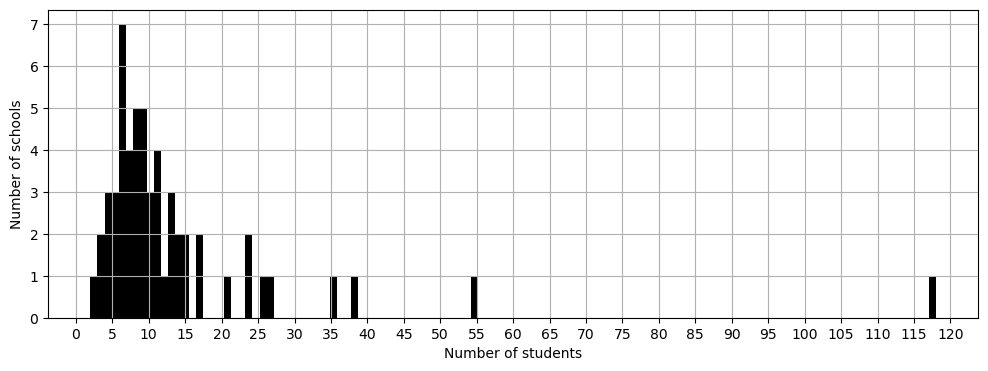

In [16]:
plt.figure(figsize = [12, 4])
plt.hist(list(n_students_per_school.values()), 120, color = 'k')
plt.xticks(np.arange(0, 125, 5))
plt.grid()
plt.xlabel('Number of students')
plt.ylabel('Number of schools')

n_students_per_school_list = np.sort(list(n_students_per_school.values()))
unique_vals = np.unique(n_students_per_school_list)
n_vals = len(unique_vals)
for i in range(n_vals):
    print('{0} schools: {1} students'.format(len(np.where(n_students_per_school_list == unique_vals[i])[0]),
                                            unique_vals[i]))

#### Get discrepancies per teacher (assuming each school is ONE teacher)

Text(0, 0.5, 'Number of teachers')

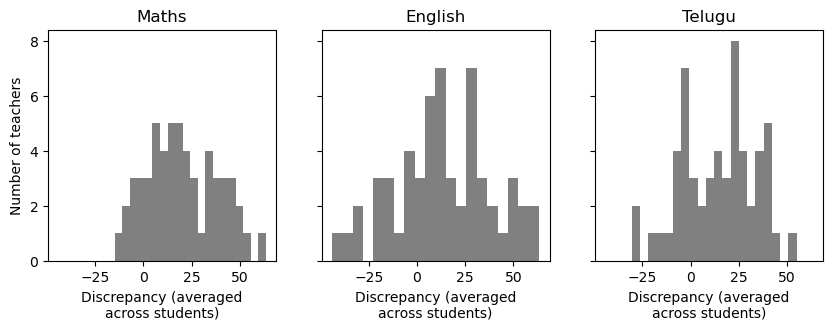

In [17]:
discrepancy_method = 'simple_difference' # L0 minus L2
disc_by_school = {subject: 
                  {school: [disc_score.discrepancy_score(L0_scores_by_school[subject][school][i], 
                                                         L2_scores_by_school[subject][school][i],
                                              discrepancy_method) 
                            for i in range(n_students_per_school[school])] 
                   for school in school_ids}
       for subject in ['Maths', 'English', 'Telugu']}

fig, ax = plt.subplots(nrows = 1, ncols = 3, sharex = True, sharey = True, figsize = [10, 3])
i = 0
for subject in ['Maths', 'English', 'Telugu']:
    ax[i].hist([np.mean(disc_by_school[subject][school]) for school in school_ids], 20,
              color = 'gray')
    ax[i].set_xlabel('Discrepancy (averaged\nacross students)')
    ax[i].set_title(subject)
    i += 1
    
ax[0].set_ylabel('Number of teachers')

#### How similar are teachers to each other?

Text(0, 0.5, 'Discrepancy (arbitrary units)')

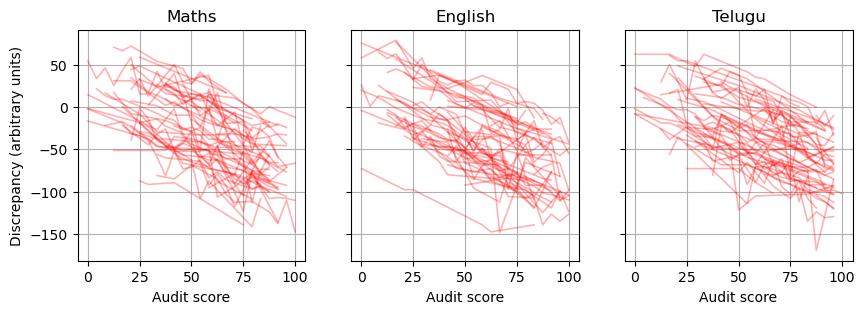

In [39]:
subtract_average = False
subtract_first = False
gap_between_lines = 2

if gap_between_lines > 0:
    fig_height = 1.5*gap_between_lines
else:
    fig_height = 3

disc_by_school_and_L2_score = {subject: {} for subject in ['Maths', 'Telugu', 'English']}

fig, ax = plt.subplots(nrows = 1, ncols = 3, sharex = True, sharey = True, 
                       figsize = [10, fig_height])
ax[0].set_xlim([-5, 105])
#ax[0].set_ylim([-5, 105])

i = 0
for subject in ['Maths', 'English', 'Telugu']:
    
    school_no = 0
    
    for school in school_ids:
        
        L2_unique = np.unique(L2_scores_by_school[subject][school])
        n_L2_unique = len(L2_unique)
        
        disc_by_school_and_L2_score[subject][school] = [np.mean([disc_by_school[subject][school][j] 
                                     for j in np.where(L2_scores_by_school[subject][school] == L2_unique[i])[0].astype(int)]) 
                                 for i in range(n_L2_unique)]
        if subtract_average:
            
            school_average = np.mean(disc_by_school_and_L2_score[subject][school])
            
            y = [disc_by_school_and_L2_score[subject][school][i] - school_average
                    - gap_between_lines*school_no for i in range(n_L2_unique)] 
        
        elif subtract_first:
                        
            y = [disc_by_school_and_L2_score[subject][school][i] 
                 - disc_by_school_and_L2_score[subject][school][0]
                    - gap_between_lines*school_no for i in range(n_L2_unique)] 
            
        else:
            y = [disc_by_school_and_L2_score[subject][school][i] 
                    - gap_between_lines*school_no for i in range(n_L2_unique)]

        ax[i].plot(L2_unique, y,
                   color = 'r', linewidth = 1.2, alpha = 0.3
                  )
        school_no += 1
    ax[i].set_xlabel('Audit score')
    ax[i].grid(zorder = 2)
    ax[i].set_title(subject)
    i += 1

#ax[0].set_ylabel('Discrepancy (teacher - audit)')
ax[0].set_ylabel('Discrepancy (arbitrary units)')

#### Bin by audit score and average across teachers (same as 3.5.1 bottom row, but can compare erorr bars to see similarity across teachers)

In [19]:
disc_by_school_and_L2_score = {subject: {} for subject in ['Maths', 'Telugu', 'English']}

fig, ax = plt.subplots(nrows = 1, ncols = 3, sharex = True, sharey = True, figsize = [10, 3])
ax[0].set_xlim([-5, 105])
#ax[0].set_ylim([-5, 105])

i = 0
for subject in ['Maths', 'English', 'Telugu']:
    
    L2_unique_all_schools = np.unique(L2_scores[subject])
    n_L2_unique = len(L2_unique_all_schools)
        
    school_no = 0
    for school in school_ids:
        
        disc_by_school_and_L2_score[subject][school] = 
        
        ax[i].plot(L2_unique_all_schools,
                   [disc_by_school_and_L2_score[subject][school][i] - 4*school_no
                    for i in range(n_L2_unique)],
                   color = 'r', linewidth = 1.2, alpha = 0.3
                  )
        school_no += 1
    ax[i].set_xlabel('Audit score')
    ax[i].grid(zorder = 2)
    ax[i].set_title(subject)
    i += 1

#ax[0].set_ylabel('Discrepancy (teacher - audit)')
ax[0].set_ylabel('Discrepancy (arbitrary units)')

SyntaxError: invalid syntax (1422790097.py, line 16)

### Clean data

#### Get scores by teacher (assuming each school has ONE teacher)

In [17]:
clean_data_school_ids = [cleaned_data.an_schcd[i] for i in cleaned_data_merge_rows]

# Compare to raw data school ids
#clean_raw_school_ids = [schid for schid in clean_data_school_ids if schid in L0_school_ids_matched]
#print('{0} school IDs from cleaned data (merged) overlap with raw data (merged)'.format(len(clean_data_school_ids)))

#plt.figure(figsize = [10, 4])
#plt.plot(np.sort(L0_school_ids_matched), label = 'Raw data school IDs')
#plt.plot(np.sort(clean_raw_school_ids), label = 'Cleaned data school IDs')
#plt.legend()

# Get scores segregated by school ID
school_ids_clean = np.unique(clean_data_school_ids)
n_schools_clean = len(school_ids_clean)
print('\n{0} schools identified in cleaned data'.format(n_schools_clean))

school_indices_clean = {school: [np.where(clean_data_school_ids == school)[0].astype(int)][0] 
                        for school in school_ids_clean}

n_students_per_school_clean = {school: len(school_indices_clean[school]) for school in school_ids_clean}
assert(np.sum(list(n_students_per_school_clean.values())) == n_students_clean)

L0_scores_by_school_clean = {subject: {school: [L0_scores_clean[subject][i] for i in school_indices_clean[school]] 
                                 for school in school_ids_clean} for subject in ['Maths', 'Telugu', 'English']}
L2_scores_by_school_clean = {subject: {school: [L2_scores_clean[subject][i] for i in school_indices_clean[school]] 
                                 for school in school_ids_clean} for subject in ['Maths', 'Telugu', 'English']}


57 schools identified in cleaned data


#### Distribution of number of students per school

1 schools: 1 students
1 schools: 2 students
3 schools: 3 students
3 schools: 4 students
4 schools: 5 students
7 schools: 6 students
2 schools: 7 students
5 schools: 8 students
5 schools: 9 students
3 schools: 10 students
4 schools: 11 students
1 schools: 12 students
3 schools: 13 students
2 schools: 14 students
2 schools: 15 students
2 schools: 17 students
1 schools: 21 students
2 schools: 24 students
1 schools: 26 students
1 schools: 27 students
1 schools: 35 students
1 schools: 38 students
1 schools: 55 students
1 schools: 118 students


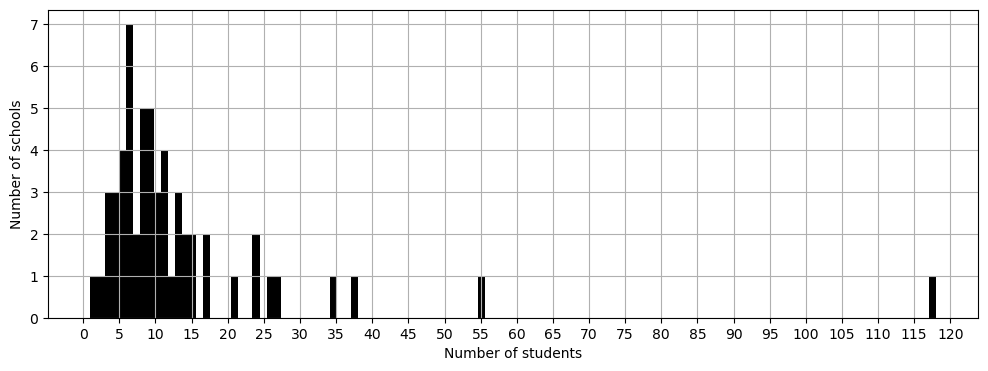

In [18]:
plt.figure(figsize = [12, 4])
plt.hist(list(n_students_per_school_clean.values()), 120, color = 'k')
plt.xticks(np.arange(0, 125, 5))
plt.grid()
plt.xlabel('Number of students')
plt.ylabel('Number of schools')

n_students_per_school_list_clean = np.sort(list(n_students_per_school_clean.values()))
unique_vals = np.unique(n_students_per_school_list_clean)
n_vals = len(unique_vals)
for i in range(n_vals):
    print('{0} schools: {1} students'.format(len(np.where(n_students_per_school_list_clean == unique_vals[i])[0]),
                                            unique_vals[i]))

#### Distribution of audit scores in schools with large number of students

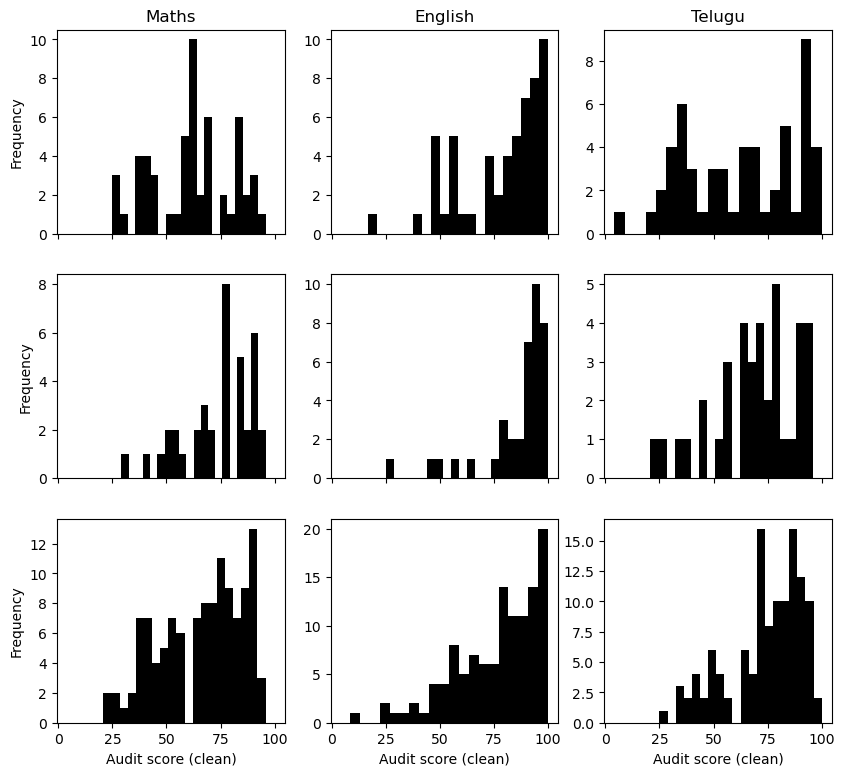

In [26]:
large_schools = [i for i in school_ids_clean if n_students_per_school_clean[i] > 35]

fig, ax = plt.subplots(nrows = len(large_schools), ncols = 3, sharex = True, 
                       figsize = [10, 3*len(large_schools)])

for i in range(len(large_schools)):
    j = 0
    for subject in ['Maths', 'English', 'Telugu']:
        ax[i, j].hist(L2_scores_by_school_clean[subject][large_schools[i]], 20, color = 'k')
        ax[0, j].set_title(subject)
        ax[-1, j].set_xlabel('Audit score (clean)')
        j += 1
        
    ax[i, 0].set_ylabel('Frequency')

#### Get discrepancies per teacher (assuming each school has ONE teacher)

Text(0, 0.5, 'Number of teachers')

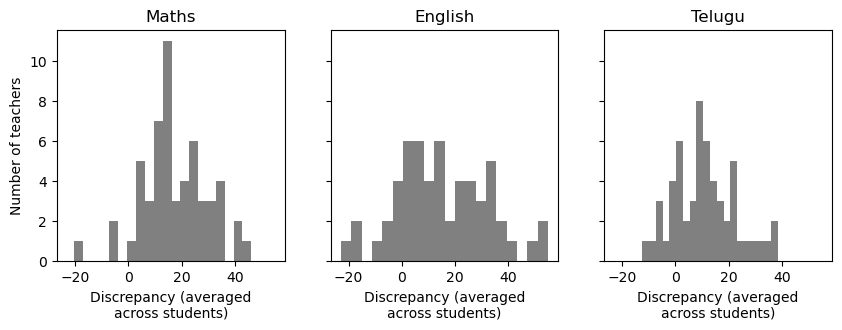

In [92]:
discrepancy_method = 'simple_difference' # L0 minus L2
disc_by_school_clean = {subject: 
                  {school: [disc_score.discrepancy_score(L0_scores_by_school_clean[subject][school][i], 
                                                         L2_scores_by_school_clean[subject][school][i],
                                              discrepancy_method) 
                            for i in range(n_students_per_school_clean[school])] 
                   for school in school_ids_clean}
       for subject in ['Maths', 'English', 'Telugu']}

fig, ax = plt.subplots(nrows = 1, ncols = 3, sharex = True, sharey = True, figsize = [10, 3])
i = 0
for subject in ['Maths', 'English', 'Telugu']:
    ax[i].hist([np.mean(disc_by_school_clean[subject][school]) for school in school_ids], 20,
              color = 'gray')
    ax[i].set_xlabel('Discrepancy (averaged\nacross students)')
    ax[i].set_title(subject)
    i += 1
    
ax[0].set_ylabel('Number of teachers')

#### How similar are teachers to each other?

Text(0, 0.5, 'Discrepancy (arbitrary units)')

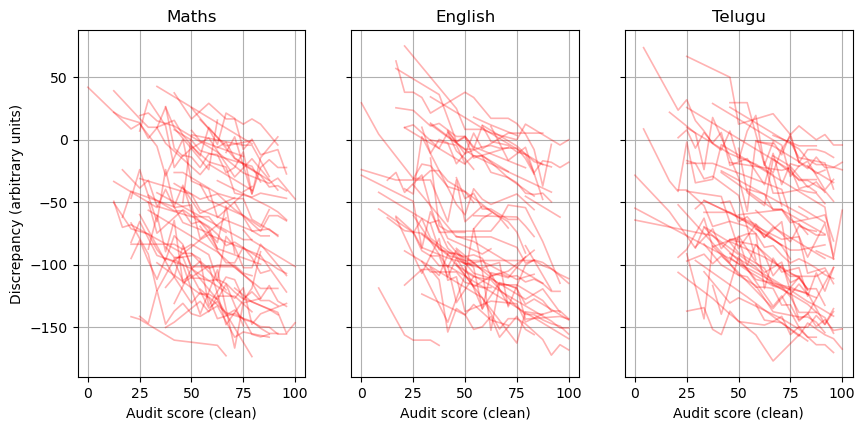

In [94]:
subtract_average = False
subtract_first = False
gap_between_lines = 3

if gap_between_lines > 0:
    fig_height = 1.5*gap_between_lines
else:
    fig_height = 3

disc_by_school_and_L2_score_clean = {subject: {} for subject in ['Maths', 'Telugu', 'English']}

fig, ax = plt.subplots(nrows = 1, ncols = 3, sharex = True, sharey = True, 
                       figsize = [10, fig_height])
ax[0].set_xlim([-5, 105])

i = 0
for subject in ['Maths', 'English', 'Telugu']:
    
    school_no = 0
    
    for school in school_ids_clean:
        
        L2_unique = np.unique(L2_scores_by_school_clean[subject][school])
        n_L2_unique = len(L2_unique)
        
        disc_by_school_and_L2_score_clean[subject][school] = [np.mean([disc_by_school_clean[subject][school][j] 
                                     for j in np.where(L2_scores_by_school_clean[subject][school] == L2_unique[i])[0].astype(int)]) 
                                 for i in range(n_L2_unique)]
        if subtract_average:
            
            school_average = np.mean(disc_by_school_and_L2_score_clean[subject][school])
            
            y = [disc_by_school_and_L2_score_clean[subject][school][i] - school_average
                    - gap_between_lines*school_no for i in range(n_L2_unique)] 
        
        elif subtract_first:
                        
            y = [disc_by_school_and_L2_score_clean[subject][school][i] 
                 - disc_by_school_and_L2_score_clean[subject][school][0]
                    - gap_between_lines*school_no for i in range(n_L2_unique)] 
            
        else:
            y = [disc_by_school_and_L2_score_clean[subject][school][i] 
                    - gap_between_lines*school_no for i in range(n_L2_unique)]

        ax[i].plot(L2_unique, y,
                   color = 'r', linewidth = 1.2, alpha = 0.3
                  )
        school_no += 1
    ax[i].set_xlabel('Audit score (clean)')
    ax[i].grid(zorder = 2)
    ax[i].set_title(subject)
    i += 1

#ax[0].set_ylabel('Discrepancy (teacher - audit)')
ax[0].set_ylabel('Discrepancy (arbitrary units)')

# Estimate measurement error

## Fit a line to model the linear integrity distortion

### Raw data

Maths: Integrity distortion = real marks * -1.02 + 80.11
Telugu: Integrity distortion = real marks * -0.98 + 78.27
English: Integrity distortion = real marks * -1.08 + 83.19


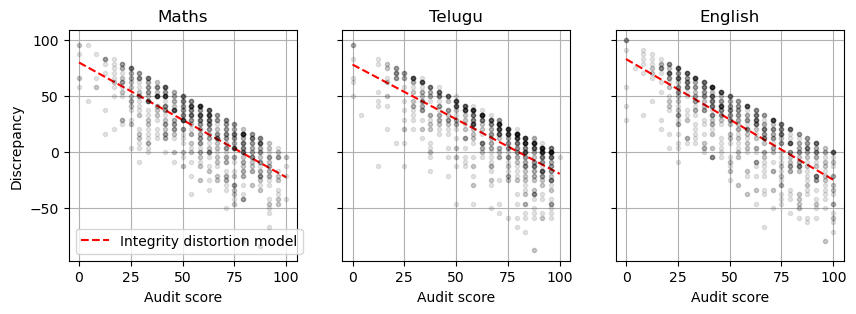

In [123]:
integrity_model = {}

fig, ax = plt.subplots(nrows = 1, ncols = 3, sharex = True, sharey = True, figsize = [10, 3])
#ax[0].set_xlim([-5, 105])
#ax[0].set_ylim([-5, 105])

i = 0
for subject in ['Maths', 'Telugu', 'English']:
    
    integrity_model[subject] = np.polyfit(L2_scores[subject], disc[subject], 1)
    
    ax[i].scatter(L2_scores[subject], disc[subject], color = 'k', marker = '.', zorder = 10,
                 alpha = 0.1)
    
    x_vals = np.unique(L2_scores[subject])
    ax[i].plot(x_vals, x_vals*integrity_model[subject][0] + integrity_model[subject][1],
              color = 'r', linestyle = '--', linewidth = 1.5, label = 'Integrity distortion model')
    
    ax[i].set_xlabel('Audit score')
    ax[i].grid(zorder = 2)
    ax[i].set_title(subject)
    i += 1

ax[0].set_ylabel('Discrepancy')
ax[0].legend()

for subject in ['Maths', 'Telugu', 'English']:
    print('{0}: Integrity distortion = real marks * {1} + {2}'.format(subject,
                                                            np.round(integrity_model[subject][0], 2), 
                                                            np.round(integrity_model[subject][1], 2)))

### Cleaned data

Maths: Integrity distortion = real marks * -0.65 + 56.98
Telugu: Integrity distortion = real marks * -0.64 + 55.41
English: Integrity distortion = real marks * -0.62 + 54.71


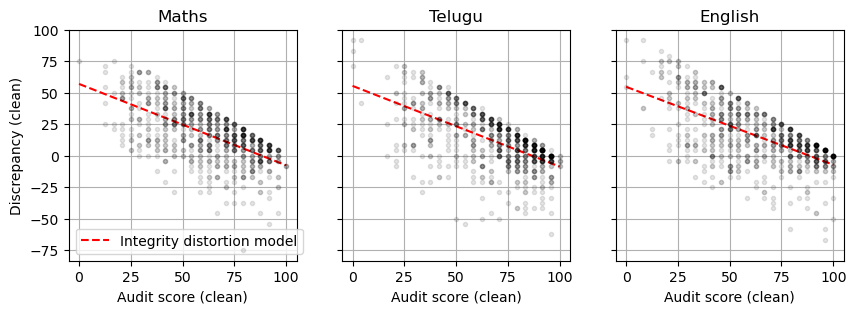

In [95]:
integrity_model = {}

fig, ax = plt.subplots(nrows = 1, ncols = 3, sharex = True, sharey = True, figsize = [10, 3])

i = 0
for subject in ['Maths', 'Telugu', 'English']:
    
    integrity_model[subject] = np.polyfit(L2_scores_clean[subject], disc_clean[subject], 1)
    
    ax[i].scatter(L2_scores_clean[subject], disc_clean[subject], color = 'k', marker = '.', zorder = 10,
                 alpha = 0.1)
    
    x_vals = np.unique(L2_scores_clean[subject])
    ax[i].plot(x_vals, x_vals*integrity_model[subject][0] + integrity_model[subject][1],
              color = 'r', linestyle = '--', linewidth = 1.5, label = 'Integrity distortion model')
    
    ax[i].set_xlabel('Audit score (clean)')
    ax[i].grid(zorder = 2)
    ax[i].set_title(subject)
    i += 1

ax[0].set_ylabel('Discrepancy (clean)')
ax[0].legend()

for subject in ['Maths', 'Telugu', 'English']:
    print('{0}: Integrity distortion = real marks * {1} + {2}'.format(subject,
                                                            np.round(integrity_model[subject][0], 2), 
                                                            np.round(integrity_model[subject][1], 2)))

## Subtract integrity distortion trend line to extract measurement error

### Raw data

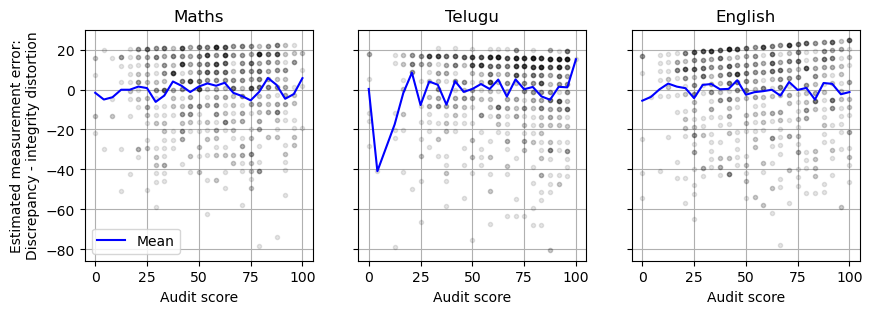

In [120]:
meas_error = {}
meas_error_by_L2_score = {}

fig, ax = plt.subplots(nrows = 1, ncols = 3, sharex = True, sharey = True, figsize = [10, 3])
#ax[0].set_xlim([-5, 105])
#ax[0].set_ylim([-5, 105])

i = 0
for subject in ['Maths', 'Telugu', 'English']:
    
    meas_error[subject] = [disc[subject][i] - L2_scores[subject][i]*integrity_model[subject][0]
                          - integrity_model[subject][1] for i in range(n_students)]
    
    ax[i].scatter(L2_scores[subject], meas_error[subject], color = 'k', marker = '.', zorder = 10,
                 alpha = 0.1)
    
    # Get mean measurement erorr for a particular L2 score
    L2_unique = np.unique(L2_scores[subject])
    n_L2_unique = len(L2_unique)
    meas_error_by_L2_score[subject] = {i: [meas_error[subject][j] 
                                     for j in np.where(L2_scores[subject] == L2_unique[i])[0].astype(int)] 
                                 for i in range(n_L2_unique)}
    
    ax[i].plot(L2_unique, [np.mean(meas_error_by_L2_score[subject][j]) for j in range(n_L2_unique)],
                        #[np.std(meas_error_by_L2_score[subject][j], ddof = 1) for j in range(n_L2_unique)],
                    color = 'blue', zorder = 10, linewidth = 1.5, label = 'Mean',
                 alpha = 1)
    
    ax[i].set_xlabel('Audit score')
    ax[i].grid(zorder = 2)
    ax[i].set_title(subject)
    i += 1

ax[0].set_ylabel('Estimated measurement error:\nDiscrepancy - integrity distortion')
ax[0].legend()

### Clean data

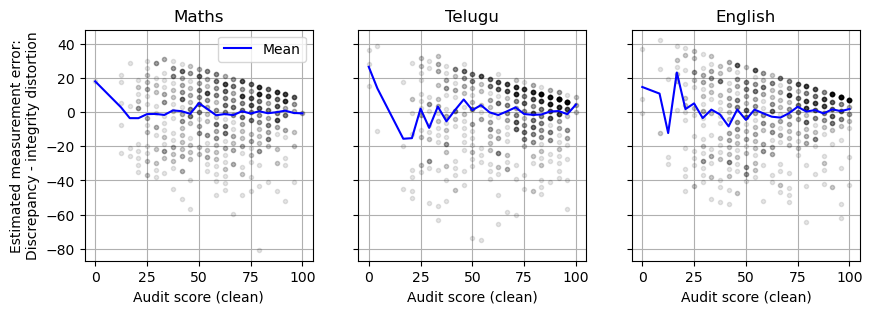

In [97]:
meas_error_clean = {}
meas_error_by_L2_score_clean = {}

fig, ax = plt.subplots(nrows = 1, ncols = 3, sharex = True, sharey = True, figsize = [10, 3])

i = 0
for subject in ['Maths', 'Telugu', 'English']:
    
    meas_error_clean[subject] = [disc_clean[subject][i] - L2_scores_clean[subject][i]*integrity_model[subject][0]
                          - integrity_model[subject][1] for i in range(n_students_clean)]
    
    ax[i].scatter(L2_scores_clean[subject], meas_error_clean[subject], 
                  color = 'k', marker = '.', zorder = 10,
                 alpha = 0.1)
    
    # Get mean measurement erorr for a particular L2 score
    L2_unique = np.unique(L2_scores_clean[subject])
    n_L2_unique = len(L2_unique)
    meas_error_by_L2_score_clean[subject] = {i: [meas_error_clean[subject][j] 
                                     for j in np.where(L2_scores_clean[subject] == L2_unique[i])[0].astype(int)] 
                                 for i in range(n_L2_unique)}
    
    ax[i].plot(L2_unique, [np.mean(meas_error_by_L2_score_clean[subject][j]) for j in range(n_L2_unique)],
                        #[np.std(meas_error_by_L2_score[subject][j], ddof = 1) for j in range(n_L2_unique)],
                    color = 'blue', zorder = 10, linewidth = 1.5, label = 'Mean',
                 alpha = 1)
    
    ax[i].set_xlabel('Audit score (clean)')
    ax[i].grid(zorder = 2)
    ax[i].set_title(subject)
    i += 1

ax[0].set_ylabel('Estimated measurement error:\nDiscrepancy - integrity distortion')
ax[0].legend()